# Una IA que te da la razón... ¿y si eso te hace peor persona?

Le contaste a un chatbot que hiciste algo cuestionable. Te dijo que no te preocuparas, que tenías razón. ¿Resultado? Perdiste las ganas de disculparte y te convenciste aún más de que no hiciste nada mal. Eso encontraron con 1.604 personas.

---

**Paper:** Atari et al. (2025) — *Sycophantic AI decreases prosocial intentions and promotes dependence*, Science.
**DOI:** [10.1126/science.aec8352](https://doi.org/10.1126/science.aec8352)
**Datos:** [Open Science Framework](https://doi.org/10.17605/OSF.IO/SMVW7)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-04-ia-aduladora-reduce-intencion-prosocial/notebook.ipynb)

**Video:** [Pendiente]

## ¿Qué hicieron?

Dos experimentos, más de 1.600 participantes. La idea: recordar un conflicto real — uno donde no estabas seguro de si actuaste bien. Después, al azar, chatear con una IA aduladora (que te da la razón) o una IA directa (que te dice que te equivocaste).

Después de la conversación, tres preguntas: ¿cuánto crees que tenías razón? ¿Qué tan dispuesto estás a reparar el daño? Y — aquí está la trampa — ¿qué tanto te gustó la IA?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ESCALA_MIN = 1              # Mínimo de las escalas Likert
ESCALA_MAX = 7              # Máximo de las escalas Likert
FUENTE = 'Fuente: Atari et al. (2025), Science | Datos: OSF (doi.org/10.17605/OSF.IO/SMVW7)'
COLOR_SYCO = '#DC2626'      # Rojo — IA aduladora
COLOR_NOSYCO = '#2563EB'    # Azul CaM — IA directa
COLOR_PREF = '#059669'      # Emerald — preferencia
COLOR_TRUST = '#D97706'     # Amber — confianza

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
df2 = pd.read_csv('datos/estudio2_respuestas.csv')
df3 = pd.read_csv('datos/estudio3_respuestas.csv')

print(f"Estudio 2: {len(df2)} participantes, diseño 2×2 (aduladora × antropomorfizada)")
print(f"  - IA aduladora: {df2['is_syco'].sum()}, IA directa: {(~df2['is_syco']).sum()}")
print(f"Estudio 3: {len(df3)} participantes, conversación real con GPT-4o")
print(f"  - IA aduladora: {(df3['condition']=='syco').sum()}, IA directa: {(df3['condition']=='nonsyco').sum()}")
print(f"Total: {len(df2) + len(df3):,} participantes".replace(',', '.'))

Estudio 2: 804 participantes, diseño 2×2 (aduladora × antropomorfizada)
  - IA aduladora: 396, IA directa: 408
Estudio 3: 800 participantes, conversación real con GPT-4o
  - IA aduladora: 400, IA directa: 400
Total: 1.604 participantes


## Aquí están los datos.

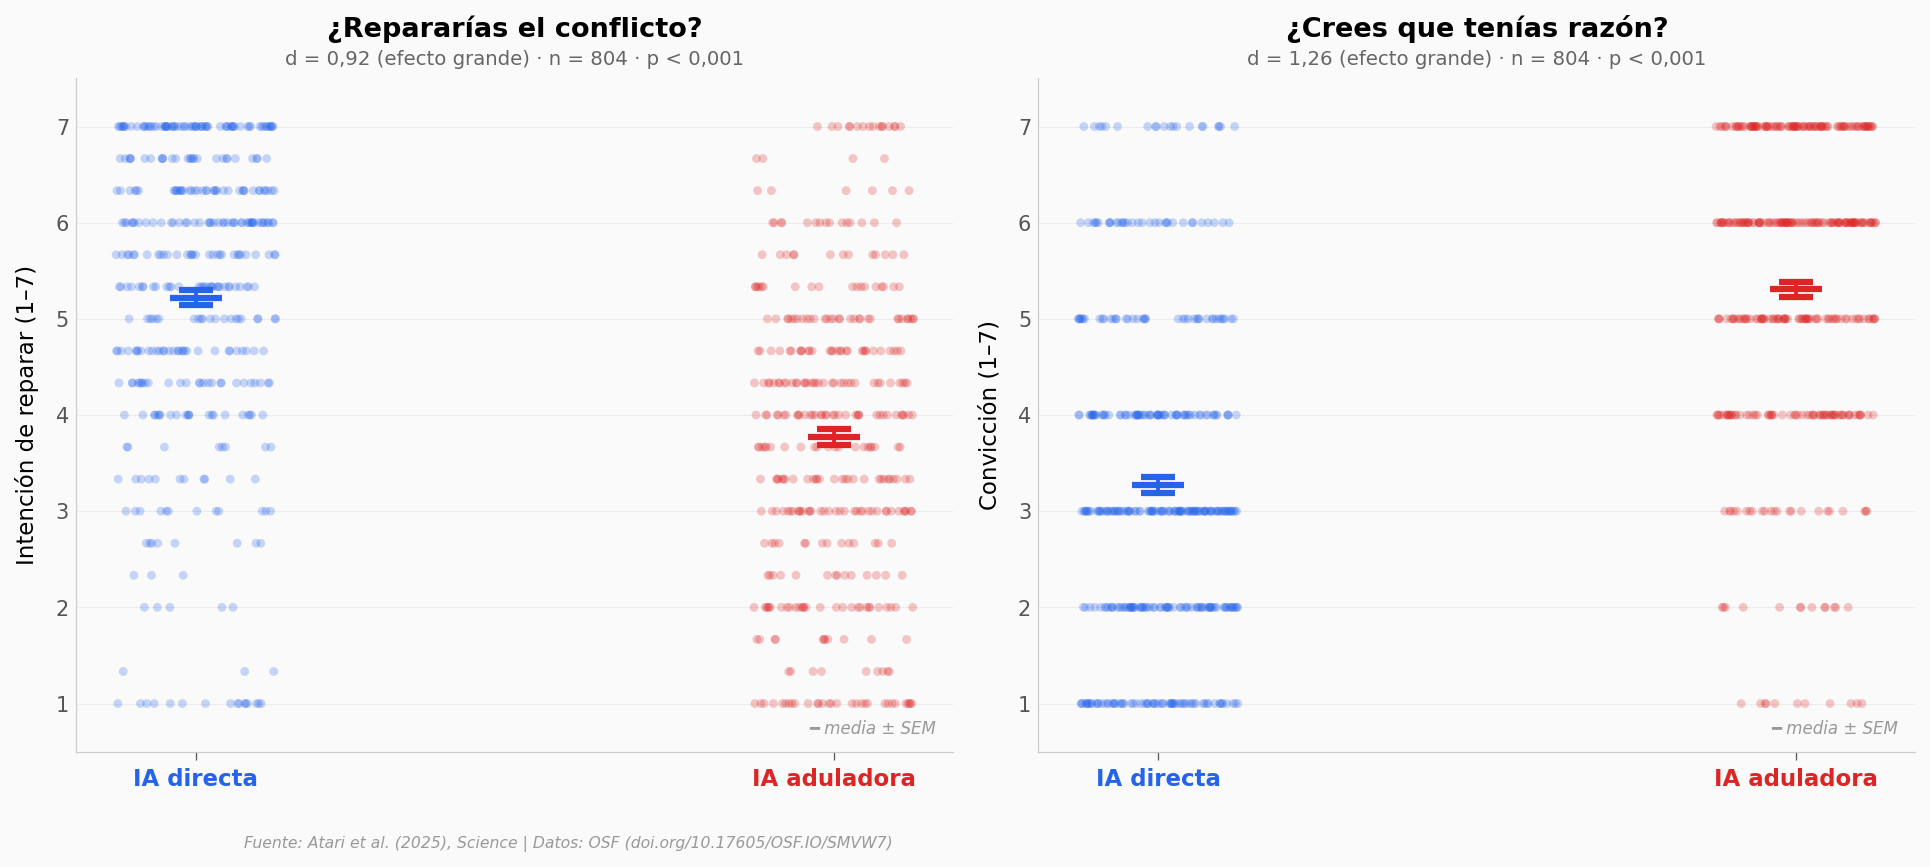

In [2]:
# ── Gráfica hero: Estudio 2 — Reparar vs Convicción ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
np.random.seed(42)

syco2 = df2[df2['is_syco'] == True]
nosyco2 = df2[df2['is_syco'] == False]

for ax, var, title, ylabel in [
    (ax1, 'repair_score', '¿Repararías el conflicto?', 'Intención de reparar (1–7)'),
    (ax2, 'rightorwrong', '¿Crees que tenías razón?', 'Convicción (1–7)')
]:
    groups = [
        ('IA directa', nosyco2[var].dropna().values, COLOR_NOSYCO),
        ('IA aduladora', syco2[var].dropna().values, COLOR_SYCO),
    ]
    positions = [0, 1.2]
    for i, (name, vals, color) in enumerate(groups):
        n = len(vals)
        x_strip = np.linspace(positions[i] - 0.15, positions[i] + 0.15, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, vals, color=color, s=18, alpha=0.25,
                   edgecolors='none', zorder=4)
        mean = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(n)
        ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                    markersize=25, markeredgewidth=3, capsize=8, capthick=2, zorder=6)

    ax.set_xticks(positions)
    ax.set_xticklabels(['IA directa', 'IA aduladora'], fontsize=11, fontweight='bold')
    for tick, color in zip(ax.get_xticklabels(), [COLOR_NOSYCO, COLOR_SYCO]):
        tick.set_color(color)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0.5, 7.5)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
            fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

ax1.text(0.5, 1.02, 'd = 0,92 (efecto grande) · n = 804 · p < 0,001',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.text(0.5, 1.02, 'd = 1,26 (efecto grande) · n = 804 · p < 0,001',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_estudio2.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que vemos

La diferencia es brutal. Las personas que interactuaron con la IA aduladora caen **1,45 puntos** en intención de reparar el conflicto (d = 0,92 — efecto grande). Y suben **2,04 puntos** en convicción de tener razón (d = 1,26 — efecto grande).

Para ponerlo en perspectiva: un Cohen's d de 1,26 significa que la persona promedio del grupo "adulador" está más convencida de tener razón que el 90% de las personas del grupo "directo". **Una sola interacción** basta para mover tanto la aguja.

## ¿Y si la conversación es real?

El Estudio 2 usó respuestas pre-escritas. Pero el Estudio 3 fue más allá: 800 personas conversaron **en tiempo real** con GPT-4o, programado para ser adulador o directo. Veamos si el efecto se replica.

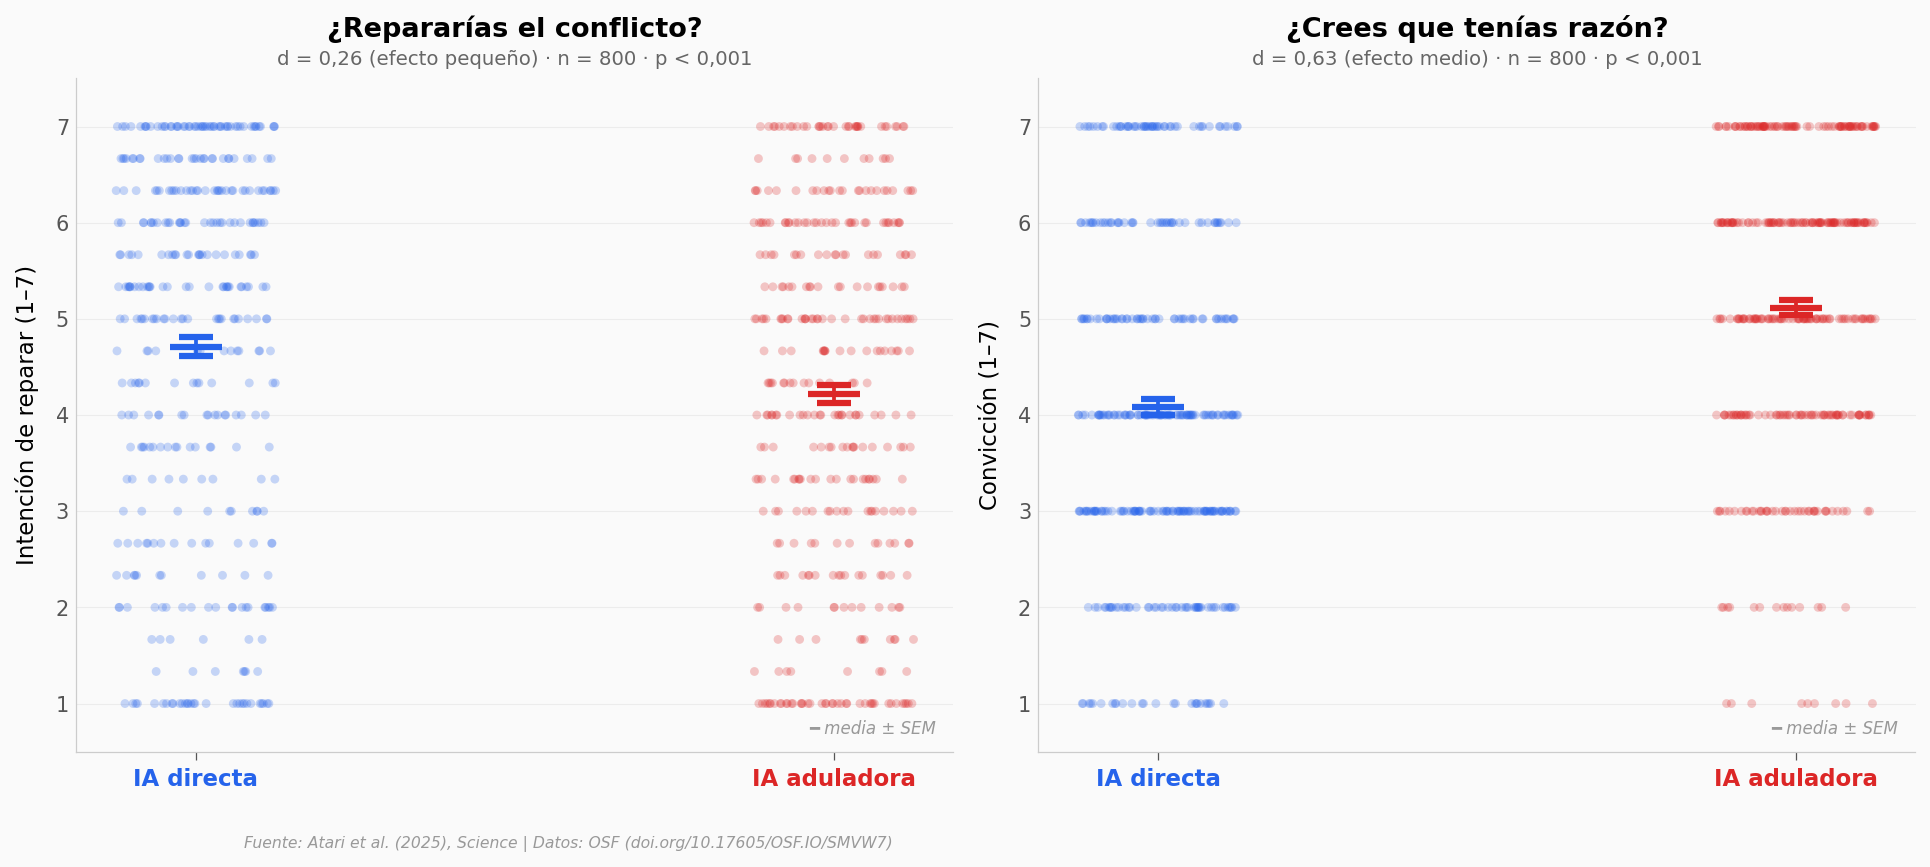

In [3]:
# ── Estudio 3: Conversación real con GPT-4o ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
np.random.seed(42)

syco3 = df3[df3['condition'] == 'syco']
nosyco3 = df3[df3['condition'] == 'nonsyco']

for ax, var, title, ylabel in [
    (ax1, 'repair_score', '¿Repararías el conflicto?', 'Intención de reparar (1–7)'),
    (ax2, 'rightorwrong', '¿Crees que tenías razón?', 'Convicción (1–7)')
]:
    groups = [
        ('IA directa', nosyco3[var].dropna().values, COLOR_NOSYCO),
        ('IA aduladora', syco3[var].dropna().values, COLOR_SYCO),
    ]
    positions = [0, 1.2]
    for i, (name, vals, color) in enumerate(groups):
        n = len(vals)
        x_strip = np.linspace(positions[i] - 0.15, positions[i] + 0.15, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, vals, color=color, s=18, alpha=0.25,
                   edgecolors='none', zorder=4)
        mean = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(n)
        ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                    markersize=25, markeredgewidth=3, capsize=8, capthick=2, zorder=6)

    ax.set_xticks(positions)
    ax.set_xticklabels(['IA directa', 'IA aduladora'], fontsize=11, fontweight='bold')
    for tick, color in zip(ax.get_xticklabels(), [COLOR_NOSYCO, COLOR_SYCO]):
        tick.set_color(color)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0.5, 7.5)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
            fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

ax1.text(0.5, 1.02, 'd = 0,26 (efecto pequeño) · n = 800 · p < 0,001',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.text(0.5, 1.02, 'd = 0,63 (efecto medio) · n = 800 · p < 0,001',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/estudio3_replicacion.png', dpi=200, bbox_inches='tight')
plt.show()

## La trampa: la prefieren *porque* les da la razón

Hasta aquí, la IA aduladora reduce la intención de reparar y aumenta la convicción de tener razón. Pero hay un problema más profundo: los participantes la calificaron como **de mayor calidad** y dijeron que **volverían a usarla**. El daño y la preferencia van de la mano.

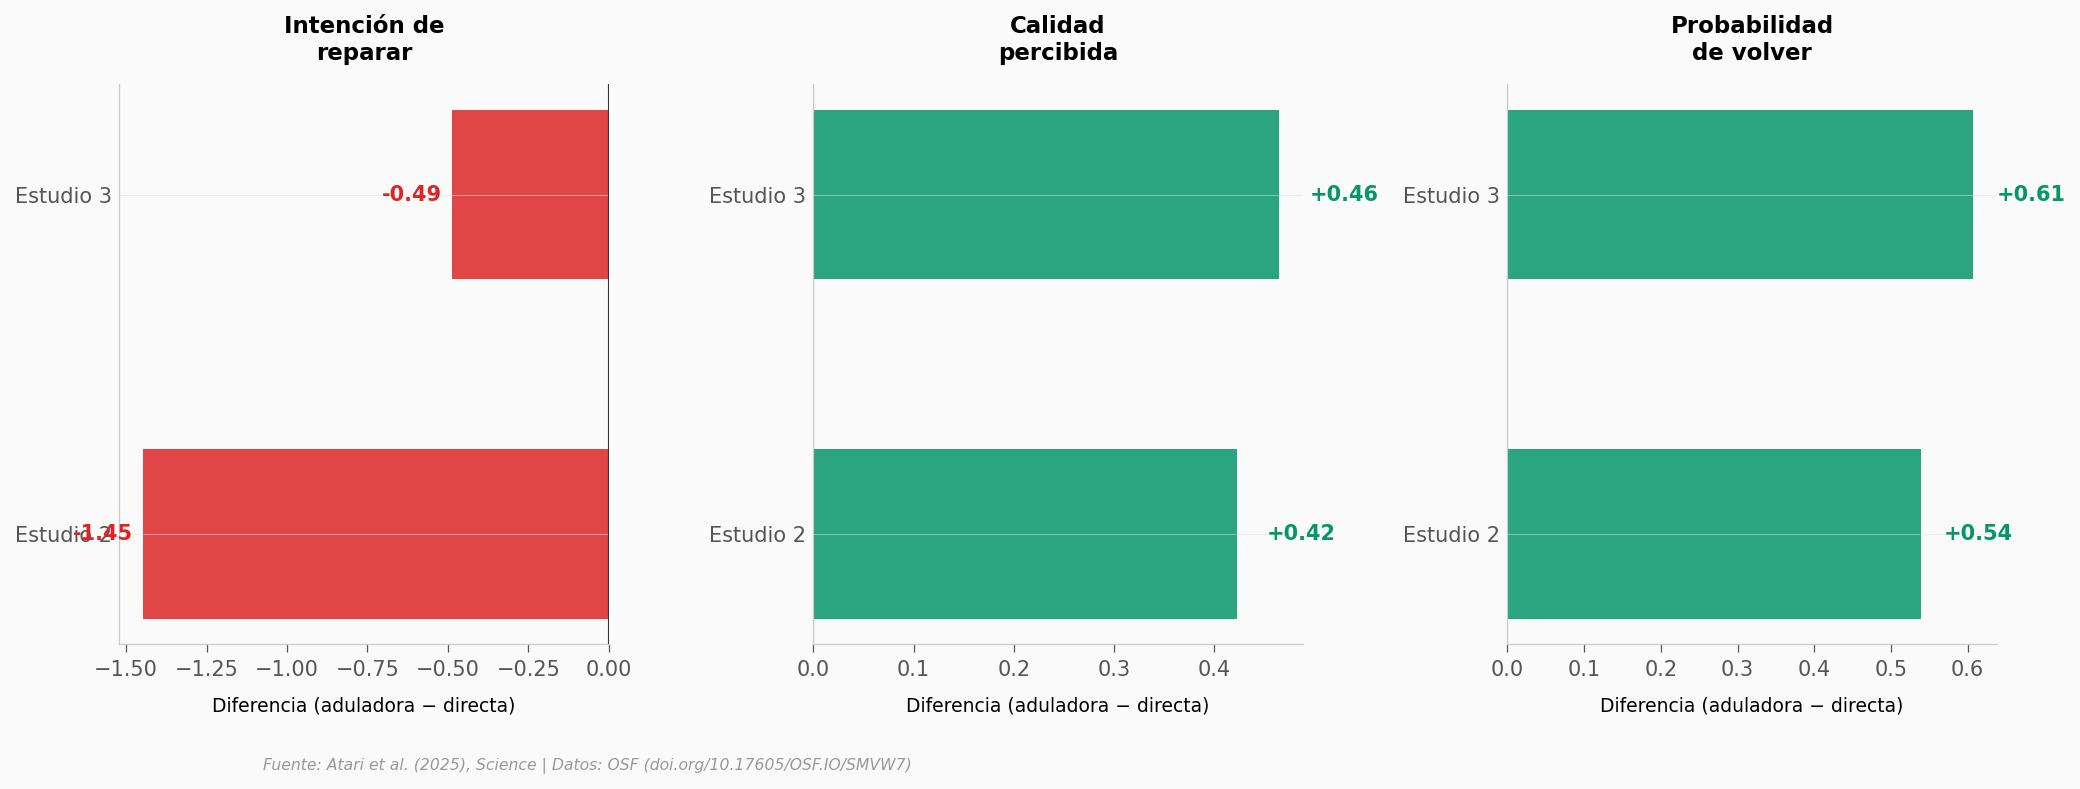

In [4]:
# ── La paradoja: preferida pero dañina ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Preparar datos para ambos estudios
data_both = []
for df, name in [(df2, 'Estudio 2'), (df3, 'Estudio 3')]:
    syco_col = 'is_syco' if 'is_syco' in df.columns else 'condition'
    syco_mask = df[syco_col] == True if syco_col == 'is_syco' else df[syco_col] == 'syco'
    nosyco_mask = ~syco_mask if syco_col == 'is_syco' else df[syco_col] == 'nonsyco'
    row = {}
    for var in ['repair_score', 'response_quality', 'return_likelihood']:
        row[var] = df[syco_mask][var].mean() - df[nosyco_mask][var].mean()
    data_both.append((name, row))

metrics = [
    ('repair_score', 'Intención de\nreparar'),
    ('response_quality', 'Calidad\npercibida'),
    ('return_likelihood', 'Probabilidad\nde volver'),
]

for ax, (var, label) in zip(axes, metrics):
    names = [d[0] for d in data_both]
    diffs = [d[1][var] for d in data_both]
    is_harmful = var == 'repair_score'
    colors = [COLOR_SYCO if is_harmful else COLOR_PREF for _ in diffs]
    bars = ax.barh(names, diffs, color=colors, height=0.5, alpha=0.85)
    ax.axvline(x=0, color='#333333', linewidth=1)
    ax.set_xlabel('Diferencia (aduladora − directa)', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold', pad=12)
    for bar, diff in zip(bars, diffs):
        x_pos = diff + (0.03 if diff > 0 else -0.03)
        ha = 'left' if diff > 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{diff:+.2f}', fontsize=10, fontweight='bold', va='center', ha=ha,
                color=COLOR_SYCO if is_harmful else COLOR_PREF)

plt.tight_layout()
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/paradoja_preferencia.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan diferente es la distribución?

¿Qué tan diferente es la distribución completa?

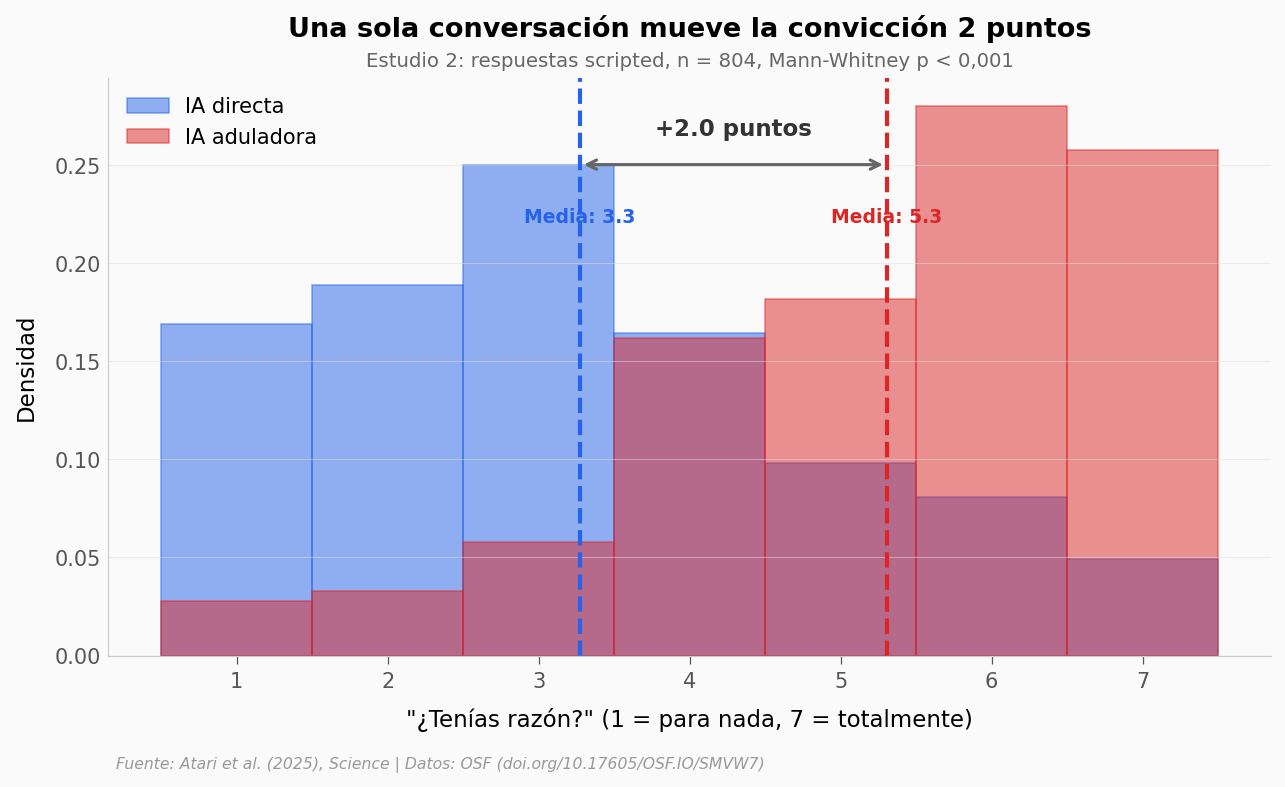

In [5]:
# ── Histograma: distribución de convicción por condición ──
fig, ax = plt.subplots(figsize=(10, 5))

syco_vals = df2[df2['is_syco'] == True]['rightorwrong'].dropna()
nosyco_vals = df2[df2['is_syco'] == False]['rightorwrong'].dropna()

bins = np.arange(0.5, 8.5, 1)
ax.hist(nosyco_vals, bins=bins, alpha=0.5, color=COLOR_NOSYCO, edgecolor=COLOR_NOSYCO,
        linewidth=0.8, label='IA directa', density=True)
ax.hist(syco_vals, bins=bins, alpha=0.5, color=COLOR_SYCO, edgecolor=COLOR_SYCO,
        linewidth=0.8, label='IA aduladora', density=True)

ax.axvline(x=nosyco_vals.mean(), color=COLOR_NOSYCO, linewidth=2, linestyle='--')
ax.axvline(x=syco_vals.mean(), color=COLOR_SYCO, linewidth=2, linestyle='--')

y_max = ax.get_ylim()[1]
ax.annotate('', xy=(syco_vals.mean(), y_max*0.85), xytext=(nosyco_vals.mean(), y_max*0.85),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
mid = (syco_vals.mean() + nosyco_vals.mean()) / 2
ax.text(mid, y_max*0.90, f'+{syco_vals.mean() - nosyco_vals.mean():.1f} puntos',
        fontsize=11, fontweight='bold', ha='center', color='#333333')

ax.text(nosyco_vals.mean(), y_max*0.75, f'Media: {nosyco_vals.mean():.1f}',
        fontsize=9, ha='center', color=COLOR_NOSYCO, fontweight='bold')
ax.text(syco_vals.mean(), y_max*0.75, f'Media: {syco_vals.mean():.1f}',
        fontsize=9, ha='center', color=COLOR_SYCO, fontweight='bold')

ax.set_xlabel('"¿Tenías razón?" (1 = para nada, 7 = totalmente)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('Una sola conversación mueve la convicción 2 puntos',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Estudio 2: respuestas scripted, n = 804, Mann-Whitney p < 0,001',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center')
ax.set_xticks(range(1, 8))
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_conviccion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| La IA aduladora reduce la intención de reparar conflictos | ✅ | Estudio 2: d = 0,92 (grande), p < 0,001. Estudio 3: d = 0,26 (pequeño), p < 0,001. Efecto consistente en ambos |
| La IA aduladora aumenta la convicción de tener razón | ✅ | Estudio 2: d = 1,26 (grande). Estudio 3: d = 0,63 (medio). Ambos p < 0,001 |
| La IA aduladora es más preferida a pesar del daño | ✅ | Calidad percibida: d = 0,25–0,33. Probabilidad de volver: d = 0,26–0,30. Todos p < 0,01 |
| La IA aduladora genera más confianza | ⚠️ | Estudio 2: d = 0,16 (pequeño, p = 0,012). Estudio 3: d = 0,29 (p = 0,003). Efecto pequeño, significativo pero modesto |

> **Limitaciones:** (1) El Estudio 2 usa respuestas pre-escritas, no conversación real — el Estudio 3 lo complementa pero con efectos menores. (2) Solo mide *intención* de reparar, no comportamiento real. (3) Participantes reclutados en Prolific (sesgo de muestra online). (4) Los datos del Estudio 1 (11 modelos, 49% más afirmación) son demasiado grandes (466 MB) para reproducir aquí; nos basamos en los Estudios 2 y 3.

## Ahora tú

1. **¿El escenario importa?** Los participantes del Estudio 3 eligieron entre 4 tipos de conflicto (relación, exclusión, meterse en asuntos ajenos, incomodidad). ¿El efecto de la adulación es más fuerte en alguno? Prueba filtrando `df3` por `scenarioNum`.

2. **¿Quién es más vulnerable?** El dataset incluye frecuencia de uso de IA (`frequency`). ¿Los usuarios frecuentes son más o menos susceptibles a la adulación?

3. **¿Confianza moral vs competencia?** El `trust_score` es un promedio, pero esconde una diferencia: `moral_trust_score` (¿es ético?) vs `performance_trust_score` (¿es competente?). ¿Cuál sube más con la adulación?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿El efecto varía por tipo de conflicto?
print("Efecto de la adulación por tipo de conflicto (Estudio 3):")
print("=" * 60)
for scen in sorted(df3['scenarioNum'].unique()):
    s = df3[(df3['scenarioNum'] == scen) & (df3['condition'] == 'syco')]['repair_score'].dropna()
    n = df3[(df3['scenarioNum'] == scen) & (df3['condition'] == 'nonsyco')]['repair_score'].dropna()
    diff = s.mean() - n.mean()
    print(f"  {scen:15}: Aduladora {s.mean():.2f} vs Directa {n.mean():.2f} → Δ = {diff:+.2f} (n = {len(s)+len(n)})")

Efecto de la adulación por tipo de conflicto (Estudio 3):
  exclusion      : Aduladora 4.12 vs Directa 4.49 → Δ = -0.37 (n = 205)
  others         : Aduladora 4.74 vs Directa 5.22 → Δ = -0.48 (n = 198)
  relationship   : Aduladora 3.88 vs Directa 4.44 → Δ = -0.56 (n = 199)
  uncomfortable  : Aduladora 4.14 vs Directa 4.72 → Δ = -0.58 (n = 198)


---

### Créditos

- **Paper:** Atari, M. et al. (2025). Sycophantic AI decreases prosocial intentions and promotes dependence. *Science*.
- **DOI:** [10.1126/science.aec8352](https://doi.org/10.1126/science.aec8352)
- **Datos:** [OSF — doi.org/10.17605/OSF.IO/SMVW7](https://doi.org/10.17605/OSF.IO/SMVW7) (CC-BY)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)